# EDA - Global Mobile Reviews Dataset

Analisis Exploratorio de Datos de resenas de telefonos moviles.

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

from src.load_data import load_csv, summary_stats
from src.cleaning import adjust_dtypes, handle_missing, remove_duplicates
from src.analysis import descriptive_stats, correlation_analysis
from src.visualization import generate_all_visualizations

## Carga de Datos 
## FASE 0 : DATOS SIN PROCESAR

In [12]:
df = load_csv('../data/dataset.csv')

DATOS SIN PROCESAR
Dimensiones: 50000 filas x 25 columnas

--- head() ---
 id_de_resenha nombre_del_cliente  edad    marca        modelo  precio_usd precio_local moneda  tasa_de_cambio_a_usd  calificacion                                                           texto_de_resenha sentimiento   pais     idioma fecha_de_resenha  compra_verificada  calificacion_duracion_bateria  calificacion_camara  calificacion_rendimiento  calificacion_disenho  calificacion_pantalla  longitud_de_resenha  numero_de_palabras  votos_utiles     fuente
             1      Aryan Maharaj    45   Realme Realme 12 Pro      337.31    ₹27996.73    INR                 83.00             2                             Not worth the money spent. Wouldn’t recommend.    Negative  India      Hindi       2023-11-06               True                              1                    1                         3                     2                      1                   46                   7             1     Amazon
    

In [13]:
summary_stats(df)


  --- Calidad de los Datos ---
  TIPOS DE DATOS:
    id_de_resenha: int64
    nombre_del_cliente: str
    edad: int64
    marca: str
    modelo: str
    precio_usd: float64
    precio_local: str
    moneda: str
    tasa_de_cambio_a_usd: float64
    calificacion: int64
    texto_de_resenha: str
    sentimiento: str
    pais: str
    idioma: str
    fecha_de_resenha: str
    compra_verificada: bool
    calificacion_duracion_bateria: int64
    calificacion_camara: int64
    calificacion_rendimiento: int64
    calificacion_disenho: int64
    calificacion_pantalla: int64
    longitud_de_resenha: int64
    numero_de_palabras: int64
    votos_utiles: int64
    fuente: str

  --- Valores Nulos ---
  No se encontraron valores nulos en ninguna columna.
  El dataset esta completo, no requiere imputacion.

  --- Duplicados ---
  No se encontraron filas duplicadas.

  --- Consistencia de Variables Categoricas ---
  marca: ['Apple', 'Google', 'Motorola', 'OnePlus', 'Realme', 'Samsung', 'Xiaomi'] (7

## FASE 1 : Analisis Descriptivo

En esta fase calculamos estadísticas descriptivas por columna para entender la distribución y las medidas  (conteo, media, mediana, desviación estándar, min, max y percentiles).
La función `descriptive_stats(df)` devuelve un DataFrame `stats_df` con estos resultados y se usa para detectar sesgos y guiar la limpieza posterior.

In [14]:
stats_df = descriptive_stats(df)


ANALISIS DESCRIPTIVO

Variables numericas (13): ['id_de_resenha', 'edad', 'precio_usd', 'tasa_de_cambio_a_usd', 'calificacion', 'calificacion_duracion_bateria', 'calificacion_camara', 'calificacion_rendimiento', 'calificacion_disenho', 'calificacion_pantalla', 'longitud_de_resenha', 'numero_de_palabras', 'votos_utiles']
Variables categoricas (11): ['nombre_del_cliente', 'marca', 'modelo', 'precio_local', 'moneda', 'texto_de_resenha', 'sentimiento', 'pais', 'idioma', 'fecha_de_resenha', 'fuente']

  --- Tendencia Central y Dispersion ---

--- Estadisticas Descriptivas (Variables Numericas) ---
+-------------------------------+----------+------------+----------+-----------+--------+-----------------+------------------+--------+----------+----------+-------------+------------+
| Variable                      | Tipo     |   No Nulos |    Media |   Mediana |   Moda |        Varianza |   Desv. Estandar |    Min |      Max |    Rango |   Asimetria |   Curtosis |
+============================

##  Limpieza y Transformacion

3.1 FASE 2 : Ajuste de tipos (`adjust_dtypes`) :
- Se convierte fechas a `datetime`, booleanos a `bool`, strings numéricos a `int/float` y columnas con pocas etiquetas a `category`.
- Ayuda a realizar cálculos, agrupaciones y visualizaciones ; reduce uso de memoria.

3.2 FASE 3 : Detección y tratamiento de datos ausentes (`handle_missing`):
- Se elimina columnas con muchos nulos (>50%). Imputa valores numéricos (por ejemplo mediana) y categóricos con la moda o `Unknown`.
- Por qué: evita errores en cálculos y modelos y mantiene calidad de datos.

3.3 Eliminacón de duplicados (`remove_duplicates`) :
- Elimina filas exactamente duplicadas y reporta cuántas se quitaron.
- Por qué: evita que duplicados inflen estadísticas y conteos.

Ejecuta la celda de abajo para aplicar estas tres operaciones y ver el resumen (`df.info()`).

In [15]:
df = adjust_dtypes(df)
df = handle_missing(df, strategy='auto')
df = remove_duplicates(df)
df.info()


AJUSTE DE TIPOS DE VARIABLES

  --- Tabla de Conversion de Tipos ---
+-------------------+-----------------+--------------+
| Columna           | Tipo Anterior   | Tipo Nuevo   |
+===================+=================+==============+
| fecha_de_resenha  | object          | datetime     |
+-------------------+-----------------+--------------+
| compra_verificada | bool            | bool         |
+-------------------+-----------------+--------------+
| marca             | str             | category (7) |
+-------------------+-----------------+--------------+
| moneda            | str             | category (8) |
+-------------------+-----------------+--------------+
| sentimiento       | str             | category (3) |
+-------------------+-----------------+--------------+
| pais              | str             | category (8) |
+-------------------+-----------------+--------------+
| idioma            | str             | category (4) |
+-------------------+-----------------+-----------

## FASE 4 :  Deteccion de Outliers

Identificamos valores atípicos en variables numéricas mediante el método IQR (rango intercuartílico).
Se reporta el número y porcentaje de outliers por columna para decidir acciones (imputación, recorte o conservación).
La revisión manual de ejemplos y la comprensión del contexto de la variable son clave antes de eliminar valores.

In [16]:
from src.cleaning import detect_outliers_iqr
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
outliers = detect_outliers_iqr(df, numeric_cols)
for col, info in outliers.items():
    if info['count'] > 0:
        print(f"{col}: {info['count']} outliers ({info['pct']}%)")

edad: 190 outliers (0.38%)
tasa_de_cambio_a_usd: 6124 outliers (12.25%)
votos_utiles: 913 outliers (1.83%)


## FASE 5 : Correlacion de Variables

## 5.1. Selección de variables numéricas
```python
df.select_dtypes(include=np.number)
```
✔ Toma solo columnas numéricas (precio, calificación, etc.)

---

## 5.2. Cálculo de correlación
```python
df.corr()
```
✔ Mide relación entre variables:
- 1 = relación fuerte
- 0 = sin relación
- -1 = relación inversa

---

## 5.3. Detección de relaciones fuertes
```python
abs(r) > 0.7
```
✔ Identifica variables muy relacionadas

---

## 5.4. Interpretación automática
- > 0.8 → muy fuerte  
- > 0.7 → fuerte  

---

## 5.5. Caso clave: precio vs satisfacción
✔ Si r ≈ 0:
 El precio no influye en la calificación

---

##  Idea principal
 El código detecta relaciones importantes y muestra si variables como precio influyen o no en la satisfacción del usuario.

In [17]:
corr = correlation_analysis(df)


CORRELACION DE VARIABLES

--- Matriz de Correlacion ---
+-------------------------------+-----------------+-------------+--------------+------------------------+----------------+---------------------------------+-----------------------+----------------------------+------------------------+-------------------------+-----------------------+----------------------+----------------+
|                               |   id_de_resenha |        edad |   precio_usd |   tasa_de_cambio_a_usd |   calificacion |   calificacion_duracion_bateria |   calificacion_camara |   calificacion_rendimiento |   calificacion_disenho |   calificacion_pantalla |   longitud_de_resenha |   numero_de_palabras |   votos_utiles |
+===============================+=================+=============+==============+========================+================+=================================+=======================+============================+========================+=========================+=======================+=========

# Interpretación de la Matriz de Correlación

- La `calificacion` general tiene una correlación positiva fuerte con:
  - `calificacion_duracion_bateria` (0.762)
  - `calificacion_camara` (0.761)
  - `calificacion_pantalla` (0.757)
  - `calificacion_rendimiento` (0.756)
  - `calificacion_disenho` (0.755)

### Interpretación
La satisfacción de los usuarios depende principalmente de las características y experiencia de uso del smartphone.

---

- La variable `precio_usd` presenta una correlación muy baja con `calificacion` (0.001).

### Interpretación
El precio no muestra una relación significativa con la satisfacción general de los usuarios.  
Esto sugiere que los usuarios valoran más el rendimiento y las características del dispositivo que su costo.

---

- `votos_utiles` presenta una correlación moderada con `calificacion` (0.460).

### Interpretación
Las reseñas con mejores calificaciones tienden a recibir más votos útiles.

---

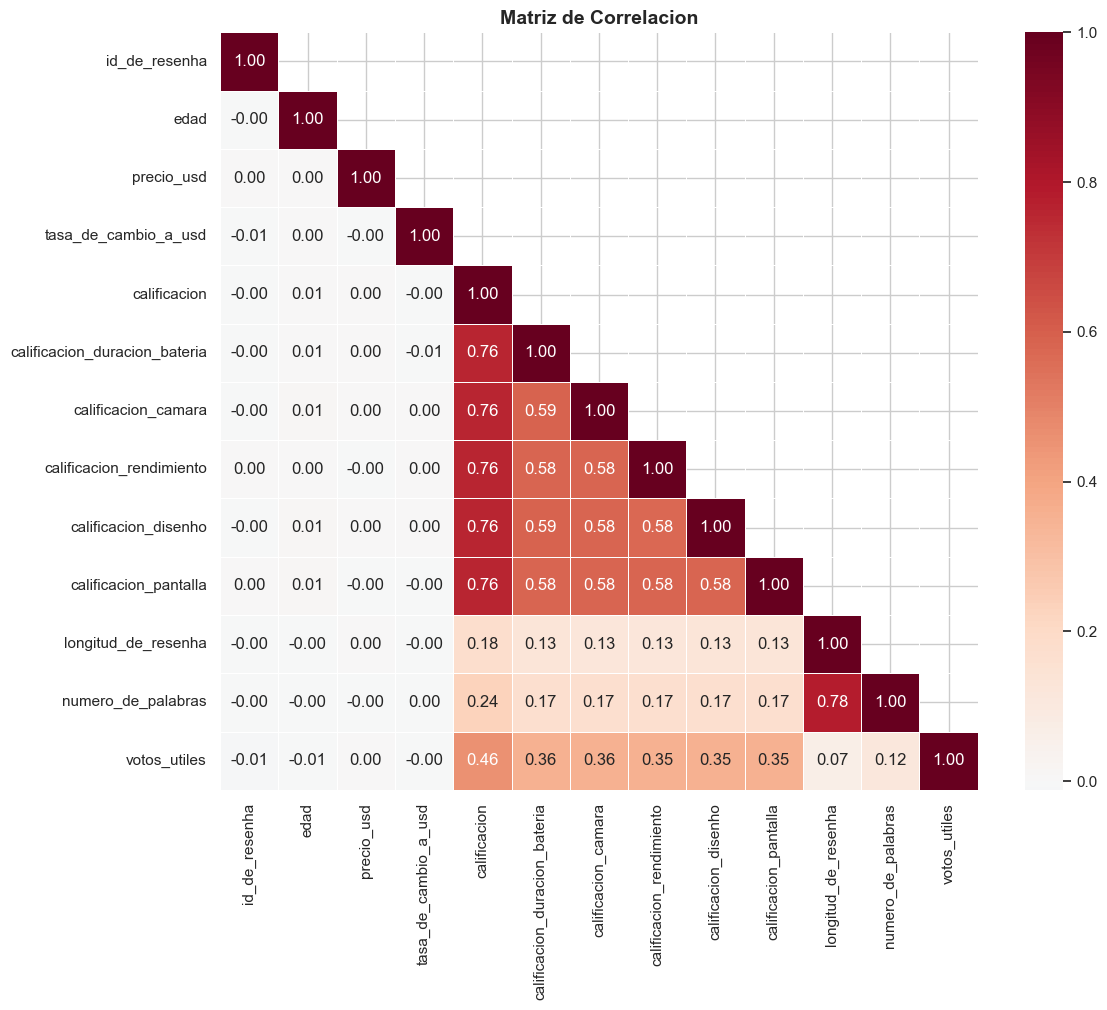

In [18]:
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlacion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Visualizaciones

In [19]:
generate_all_visualizations(df, corr)


GENERACION DE VISUALIZACIONES

  Grafico 1: Histogramas — distribucion de frecuencias de variables numericas
  id_de_resenha: media=25000.50, mediana=25000.50, asimetria=0.000 -> distribucion aproximadamente simetrica
  edad: media=30.08, mediana=29.00, asimetria=0.470 -> distribucion aproximadamente simetrica
  precio_usd: media=689.69, mediana=637.04, asimetria=0.561 -> distribucion sesgada a la derecha (asimetria positiva)
  tasa_de_cambio_a_usd: media=12.06, mediana=1.53, asimetria=2.286 -> distribucion sesgada a la derecha (asimetria positiva)
  calificacion: media=3.12, mediana=3.00, asimetria=-0.174 -> distribucion aproximadamente simetrica
  calificacion_duracion_bateria: media=2.72, mediana=3.00, asimetria=0.209 -> distribucion aproximadamente simetrica
  calificacion_camara: media=2.72, mediana=3.00, asimetria=0.206 -> distribucion aproximadamente simetrica
  calificacion_rendimiento: media=2.72, mediana=3.00, asimetria=0.202 -> distribucion aproximadamente simetrica
  calif

## 7. Visualizaciones Adicionales en Notebook

C:\Users\fredd\AppData\Local\Temp\ipykernel_35980\870788157.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="sentimiento", y="precio_usd", ax=axes[1, 2], palette="Set2")


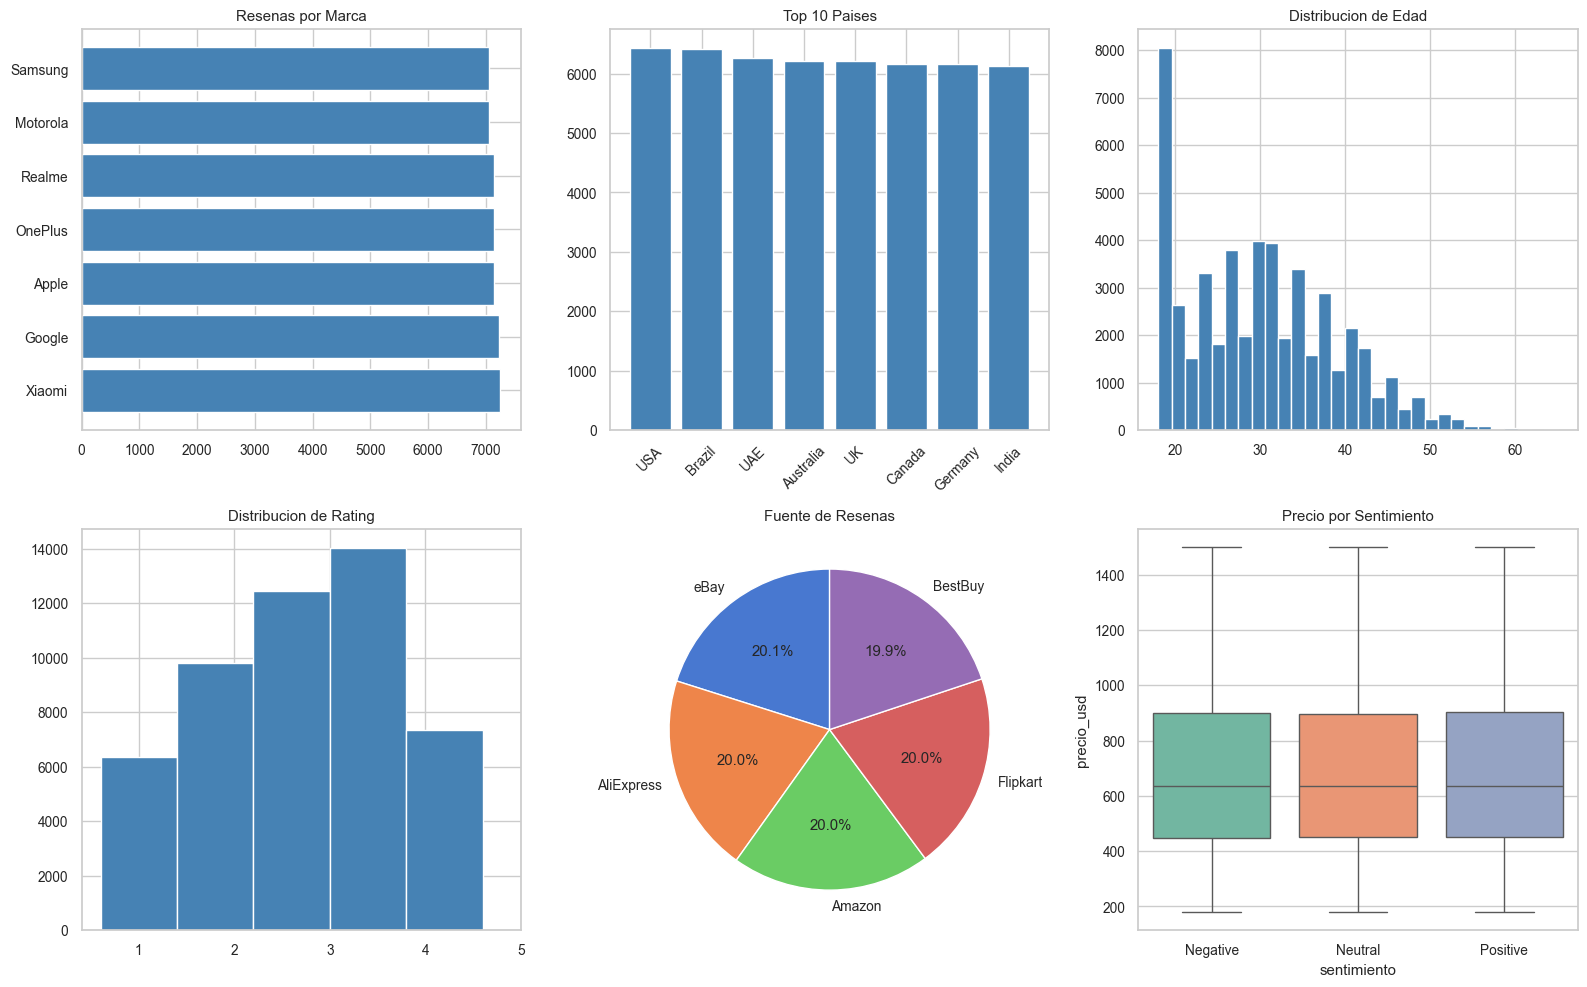

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Columnas del dataset: nombres en español (marca, pais, edad, ...)
brand_counts = df["marca"].value_counts()
axes[0, 0].barh(brand_counts.index, brand_counts.values, color="steelblue")
axes[0, 0].set_title("Resenas por Marca")

country_counts = df["pais"].value_counts().head(10)
axes[0, 1].bar(country_counts.index, country_counts.values, color="steelblue")
axes[0, 1].set_title("Top 10 Paises")
axes[0, 1].tick_params(axis="x", rotation=45)

ages = df["edad"]
axes[0, 2].hist(ages, bins=30, edgecolor="white", color="steelblue")
axes[0, 2].set_title("Distribucion de Edad")

ratings = df["calificacion"]
axes[1, 0].hist(ratings, bins=5, edgecolor="white", color="steelblue", align="left")
axes[1, 0].set_title("Distribucion de Rating")
axes[1, 0].set_xticks([1, 2, 3, 4, 5])

source_counts = df["fuente"].value_counts()
axes[1, 1].pie(
    source_counts.values,
    labels=source_counts.index,
    autopct="%1.1f%%",
    startangle=90,
)
axes[1, 1].set_title("Fuente de Resenas")

sns.boxplot(data=df, x="sentimiento", y="precio_usd", ax=axes[1, 2], palette="Set2")
axes[1, 2].set_title("Precio por Sentimiento")

plt.tight_layout()
plt.show()

In [21]:
df_clean = df.copy()
df_clean.to_csv('../data/clean_data.csv', index=False)
print(f"Dataset limpio exportado: {df_clean.shape}")

Dataset limpio exportado: (50000, 25)
